# 02 - Experimentos: iteraciones del MLP
Sección 2.2/2.3 del trabajo escrito: metodología y resultados de iteraciones.

Cada iteración cambia **una cosa** respecto a la anterior (arquitectura,
regularización, target, features) para poder atribuir el efecto. Todas se
evalúan con el mismo split train/validation (80/20, `random_state=42`) y se
reportan en **RMSE sobre `SalePrice` en escala original**, aunque algunas
iteraciones entrenen sobre una versión transformada del target (log y/o
estandarizada), para que la tabla sea comparable entre sí y con la métrica de
la competencia.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

from preprocessing import prepare_raw, build_preprocessor
from dataset import make_loader
from model import MLP
from engine import fit
from target_transform import fit_target_transform, apply_target_transform, inverse_transform_target

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

df = pd.read_csv("../data/train.csv")
df.shape

device: cuda


(1168, 81)

## Función auxiliar para correr y loguear una iteración

In [2]:
results = []
histories = {}
saved = {}


def run_experiment(iteration_id, description, changes_vs_previous, *,
                    hidden_sizes=(64,), dropout=0.0, batchnorm=False,
                    log_target=False, scale_target=False,
                    lr=1e-3, weight_decay=0.0,
                    epochs=300, patience=25, batch_size=32,
                    remove_outliers=False, seed=42, verbose=False):
    data = df.copy()
    if remove_outliers:
        mask = (data["GrLivArea"] > 4000) & (data["SalePrice"] < 200000)
        data = data[~mask].reset_index(drop=True)

    train_df, val_df = train_test_split(data, test_size=0.2, random_state=seed)

    clean_train = prepare_raw(train_df)
    clean_val = prepare_raw(val_df)

    preprocessor = build_preprocessor(clean_train)
    X_train = preprocessor.fit_transform(clean_train).astype("float32")
    X_val = preprocessor.transform(clean_val).astype("float32")

    y_train_raw = train_df["SalePrice"].values.astype("float32")
    y_val_raw = val_df["SalePrice"].values.astype("float32")
    y_train, target_stats = fit_target_transform(y_train_raw, log_target=log_target, scale_target=scale_target)
    y_val = apply_target_transform(y_val_raw, target_stats)

    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)

    torch.manual_seed(seed)
    model = MLP(input_dim=X_train.shape[1], hidden_sizes=hidden_sizes,
                dropout=dropout, batchnorm=batchnorm)
    model, history = fit(model, train_loader, val_loader, epochs=epochs, lr=lr,
                          weight_decay=weight_decay, patience=patience,
                          device=DEVICE, verbose=verbose)

    def predict_original(X):
        model.eval()
        with torch.no_grad():
            preds = model(torch.as_tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
        return inverse_transform_target(preds, target_stats)

    train_pred = predict_original(X_train)
    val_pred = predict_original(X_val)
    train_rmse = float(np.sqrt(np.mean((train_pred - y_train_raw) ** 2)))
    val_rmse = float(np.sqrt(np.mean((val_pred - y_val_raw) ** 2)))

    row = {
        "iteration_id": iteration_id,
        "description": description,
        "changes_vs_previous": changes_vs_previous,
        "hidden_sizes": str(hidden_sizes),
        "dropout": dropout,
        "batchnorm": batchnorm,
        "log_target": log_target,
        "scale_target": scale_target,
        "optimizer": "Adam",
        "lr": lr,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_rmse"]),
        "train_rmse": round(train_rmse, 2),
        "val_rmse": round(val_rmse, 2),
        "notes": "",
    }
    results.append(row)
    histories[iteration_id] = history
    saved[iteration_id] = {"model": model, "preprocessor": preprocessor, "target_stats": target_stats,
                            "input_dim": X_train.shape[1]}
    epochs_trained = row["epochs_trained"]
    print(f"{iteration_id}: train_rmse={train_rmse:,.0f}  val_rmse={val_rmse:,.0f}  epochs={epochs_trained}")
    return row, history

## Iteraciones

1. **baseline** - MLP pequeño (64,), sin regularización, target crudo.
2. **wider_deeper** - más capacidad (128, 64), target crudo.
3. **regularized (falla)** - agrega dropout + batchnorm sobre iter2, target
   crudo -> **el entrenamiento casi no avanza** (ver diagnóstico abajo).
4. **target_scaling (fix)** - misma arquitectura que iter3, pero con el
   target estandarizado -> corrige el estancamiento.
5. **log_target** - target `log1p` + estandarizado (SalePrice está sesgado,
   ver EDA).
6. **weight_decay** - agrega weight decay (L2) sobre iter5.
7. **remove_outliers** - quita los 2 outliers de `GrLivArea` detectados en
   el EDA.
8. **final** - combinación ganadora, con más épocas/paciencia.

In [3]:
run_experiment(
    "iter1_baseline", "MLP simple, sin regularización, target crudo",
    "punto de partida",
    hidden_sizes=(64,), dropout=0.0, batchnorm=False,
)

iter1_baseline: train_rmse=63,166  val_rmse=64,544  epochs=300


({'iteration_id': 'iter1_baseline',
  'description': 'MLP simple, sin regularización, target crudo',
  'changes_vs_previous': 'punto de partida',
  'hidden_sizes': '(64,)',
  'dropout': 0.0,
  'batchnorm': False,
  'log_target': False,
  'scale_target': False,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'epochs_trained': 300,
  'train_rmse': 63165.97,
  'val_rmse': 64544.12,
  'notes': ''},
 {'train_rmse': [196496.421875,
   196488.734375,
   196475.75,
   196456.984375,
   196432.25,
   196401.203125,
   196363.21875,
   196318.9375,
   196267.8125,
   196210.625,
   196147.171875,
   196076.578125,
   195999.3125,
   195917.984375,
   195826.75,
   195732.765625,
   195630.1875,
   195524.71875,
   195411.34375,
   195293.0,
   195168.171875,
   195036.875,
   194901.640625,
   194761.578125,
   194615.921875,
   194465.234375,
   194306.25,
   194143.203125,
   193974.453125,
   193804.03125,
   193626.3125,
   193444.171875,
   193258.921875,
   193067.328125,
  

In [4]:
run_experiment(
    "iter2_wider_deeper", "MLP más grande (128, 64)",
    "vs iter1: más capas/neuronas",
    hidden_sizes=(128, 64), dropout=0.0, batchnorm=False,
)

iter2_wider_deeper: train_rmse=28,096  val_rmse=29,235  epochs=210


({'iteration_id': 'iter2_wider_deeper',
  'description': 'MLP más grande (128, 64)',
  'changes_vs_previous': 'vs iter1: más capas/neuronas',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.0,
  'batchnorm': False,
  'log_target': False,
  'scale_target': False,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'epochs_trained': 210,
  'train_rmse': 28095.72,
  'val_rmse': 29234.98,
  'notes': ''},
 {'train_rmse': [196490.5,
   196416.515625,
   196136.546875,
   195463.078125,
   194182.609375,
   192055.515625,
   188897.96875,
   184476.734375,
   178733.296875,
   171479.234375,
   162686.65625,
   152263.125,
   140644.203125,
   127686.390625,
   114348.734375,
   100352.171875,
   86364.09375,
   73520.0234375,
   62508.890625,
   53627.2265625,
   47217.81640625,
   43515.3046875,
   41139.18359375,
   39834.859375,
   39114.546875,
   38569.875,
   38243.2421875,
   37946.58984375,
   37685.234375,
   37436.3671875,
   37217.66796875,
   37002.7578125,
   36804.1992

### iter3: agregar dropout + batchnorm (esto falla)

In [5]:
run_experiment(
    "iter3_regularized_FAILS", "Igual que iter2 + dropout 0.2 + batchnorm, target crudo",
    "vs iter2: agrega dropout y batchnorm para controlar overfitting",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True,
)

iter3_regularized_FAILS: train_rmse=186,005  val_rmse=189,608  epochs=300


({'iteration_id': 'iter3_regularized_FAILS',
  'description': 'Igual que iter2 + dropout 0.2 + batchnorm, target crudo',
  'changes_vs_previous': 'vs iter2: agrega dropout y batchnorm para controlar overfitting',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': False,
  'scale_target': False,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'epochs_trained': 300,
  'train_rmse': 186005.34,
  'val_rmse': 189608.09,
  'notes': ''},
 {'train_rmse': [196498.21875,
   196496.171875,
   196495.734375,
   196493.265625,
   196491.375,
   196488.96875,
   196486.671875,
   196482.15625,
   196478.640625,
   196475.453125,
   196472.5,
   196462.5,
   196460.1875,
   196450.859375,
   196444.9375,
   196440.890625,
   196436.0,
   196430.890625,
   196424.859375,
   196414.171875,
   196399.90625,
   196398.3125,
   196394.546875,
   196367.15625,
   196377.703125,
   196370.265625,
   196338.015625,
   196337.953125,
   196339.34375,
   196325

**Diagnóstico:** el val_rmse de iter3 es *peor* que el baseline sin
regularización (~190k vs ~65k), y tanto train como val RMSE apenas se mueven
durante el entrenamiento (ver curva más abajo). La causa no es que
dropout/batchnorm "no sirvan": es que `SalePrice` crudo tiene una escala
enorme (media ~181k) y la salida de la red parte cerca de 0. Sin BatchNorm,
las capas intermedias pueden crecer libremente y "compensan" ese desajuste de
escala. Con BatchNorm, cada capa oculta se normaliza a media 0 / varianza 1,
así que la única forma de alcanzar la escala del target es a través de la
capa final — y Adam mueve cada parámetro a un ritmo acotado por la tasa de
aprendizaje por paso, por lo que llegar de ~0 a ~180,000 requeriría
muchísimos más pasos de los que se entrenaron. Esto es un problema conocido
de no normalizar el target en redes con BatchNorm.

**Corrección:** estandarizar el target (`scale_target=True`, ver
`src/target_transform.py`) antes de entrenar, y deshacer la transformación
sobre las predicciones antes de calcular RMSE.

In [6]:
run_experiment(
    "iter4_target_scaling_FIX", "Igual que iter3 pero con el target estandarizado",
    "vs iter3: corrige el estancamiento estandarizando SalePrice antes de entrenar",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True, scale_target=True,
)

iter4_target_scaling_FIX: train_rmse=12,528  val_rmse=27,618  epochs=54


({'iteration_id': 'iter4_target_scaling_FIX',
  'description': 'Igual que iter3 pero con el target estandarizado',
  'changes_vs_previous': 'vs iter3: corrige el estancamiento estandarizando SalePrice antes de entrenar',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': False,
  'scale_target': True,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'epochs_trained': 54,
  'train_rmse': 12527.83,
  'val_rmse': 27618.27,
  'notes': ''},
 {'train_rmse': [0.4654516577720642,
   0.3543257713317871,
   0.34124988317489624,
   0.3255762755870819,
   0.29843956232070923,
   0.2843681573867798,
   0.28686001896858215,
   0.2533726990222931,
   0.23811697959899902,
   0.2349325716495514,
   0.23307518661022186,
   0.21940648555755615,
   0.21729761362075806,
   0.2121867835521698,
   0.1978083997964859,
   0.18652303516864777,
   0.18255743384361267,
   0.18608137965202332,
   0.19312232732772827,
   0.16350390017032623,
   0.16730546951293945,
 

In [7]:
run_experiment(
    "iter5_log_target", "Igual que iter4 pero con log1p(SalePrice) + estandarizado",
    "vs iter4: prueba target log (SalePrice está sesgado a la derecha, ver EDA)",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True,
    log_target=True, scale_target=True,
)

iter5_log_target: train_rmse=13,538  val_rmse=26,637  epochs=54


({'iteration_id': 'iter5_log_target',
  'description': 'Igual que iter4 pero con log1p(SalePrice) + estandarizado',
  'changes_vs_previous': 'vs iter4: prueba target log (SalePrice está sesgado a la derecha, ver EDA)',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': True,
  'scale_target': True,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0,
  'epochs_trained': 54,
  'train_rmse': 13538.27,
  'val_rmse': 26636.58,
  'notes': ''},
 {'train_rmse': [0.424935907125473,
   0.3074411451816559,
   0.2926313281059265,
   0.27288663387298584,
   0.2441571056842804,
   0.24440905451774597,
   0.23617498576641083,
   0.2213817983865738,
   0.20391599833965302,
   0.20826613903045654,
   0.20868341624736786,
   0.2004450261592865,
   0.19909650087356567,
   0.1909334510564804,
   0.18057867884635925,
   0.18285588920116425,
   0.1775563657283783,
   0.17901895940303802,
   0.1801750361919403,
   0.16761639714241028,
   0.17469491064548492,
   0.1

In [8]:
run_experiment(
    "iter6_weight_decay", "Igual que la mejor de iter4/iter5 + weight decay 1e-4",
    "vs iter5: agrega L2 (weight_decay) al optimizador",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True,
    log_target=True, scale_target=True, weight_decay=1e-4,
)

iter6_weight_decay: train_rmse=13,460  val_rmse=26,838  epochs=54


({'iteration_id': 'iter6_weight_decay',
  'description': 'Igual que la mejor de iter4/iter5 + weight decay 1e-4',
  'changes_vs_previous': 'vs iter5: agrega L2 (weight_decay) al optimizador',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': True,
  'scale_target': True,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0001,
  'epochs_trained': 54,
  'train_rmse': 13459.73,
  'val_rmse': 26838.29,
  'notes': ''},
 {'train_rmse': [0.42462384700775146,
   0.306458443403244,
   0.29206663370132446,
   0.26922833919525146,
   0.24536533653736115,
   0.24374419450759888,
   0.23560956120491028,
   0.22163276374340057,
   0.20333506166934967,
   0.20737364888191223,
   0.20163770020008087,
   0.19856663048267365,
   0.19841882586479187,
   0.20082172751426697,
   0.17208056151866913,
   0.18225865066051483,
   0.17616404592990875,
   0.173951655626297,
   0.18437319993972778,
   0.16544324159622192,
   0.17767353355884552,
   0.17214912176132202,


In [9]:
run_experiment(
    "iter7_remove_outliers", "Igual que iter6 pero sin los outliers de GrLivArea",
    "vs iter6: remueve las 2 casas grandes y baratas detectadas en el EDA",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True,
    log_target=True, scale_target=True, weight_decay=1e-4, remove_outliers=True,
)

iter7_remove_outliers: train_rmse=11,456  val_rmse=20,454  epochs=49


({'iteration_id': 'iter7_remove_outliers',
  'description': 'Igual que iter6 pero sin los outliers de GrLivArea',
  'changes_vs_previous': 'vs iter6: remueve las 2 casas grandes y baratas detectadas en el EDA',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': True,
  'scale_target': True,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0001,
  'epochs_trained': 49,
  'train_rmse': 11455.91,
  'val_rmse': 20453.85,
  'notes': ''},
 {'train_rmse': [0.4089291989803314,
   0.27064430713653564,
   0.2528878152370453,
   0.23431307077407837,
   0.2260456383228302,
   0.24392779171466827,
   0.22305764257907867,
   0.2812790870666504,
   0.2527431845664978,
   0.21868760883808136,
   0.19811080396175385,
   0.17956191301345825,
   0.19392681121826172,
   0.17697733640670776,
   0.19027942419052124,
   0.18466883897781372,
   0.20140965282917023,
   0.18812617659568787,
   0.1846722960472107,
   0.19656486809253693,
   0.17426586151123047,
   0.20

In [10]:
run_experiment(
    "iter8_final", "Igual que la mejor combinación anterior, con más épocas/paciencia",
    "vs mejor iteración anterior: más tiempo de entrenamiento para asentar la convergencia",
    hidden_sizes=(128, 64), dropout=0.2, batchnorm=True,
    log_target=True, scale_target=True, weight_decay=1e-4, remove_outliers=True,
    epochs=500, patience=40,
)

iter8_final: train_rmse=9,054  val_rmse=20,571  epochs=103


({'iteration_id': 'iter8_final',
  'description': 'Igual que la mejor combinación anterior, con más épocas/paciencia',
  'changes_vs_previous': 'vs mejor iteración anterior: más tiempo de entrenamiento para asentar la convergencia',
  'hidden_sizes': '(128, 64)',
  'dropout': 0.2,
  'batchnorm': True,
  'log_target': True,
  'scale_target': True,
  'optimizer': 'Adam',
  'lr': 0.001,
  'weight_decay': 0.0001,
  'epochs_trained': 103,
  'train_rmse': 9053.61,
  'val_rmse': 20571.22,
  'notes': ''},
 {'train_rmse': [0.4089291989803314,
   0.27064430713653564,
   0.2528878152370453,
   0.23431307077407837,
   0.2260456383228302,
   0.24392779171466827,
   0.22305764257907867,
   0.2812790870666504,
   0.2527431845664978,
   0.21868760883808136,
   0.19811080396175385,
   0.17956191301345825,
   0.19392681121826172,
   0.17697733640670776,
   0.19027942419052124,
   0.18466883897781372,
   0.20140965282917023,
   0.18812617659568787,
   0.1846722960472107,
   0.19656486809253693,
   0.1742

## Tabla de resultados

In [11]:
log_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
log_df.to_csv("../experiments/experiments_log.csv", index=False)
log_df

,iteration_id,description,changes_vs_previous,hidden_sizes,dropout,batchnorm,log_target,scale_target,optimizer,lr,weight_decay,epochs_trained,train_rmse,val_rmse,notes
0,iter7_remove_outliers,Igual que iter6 pero sin los outliers de GrLiv...,vs iter6: remueve las 2 casas grandes y barata...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,49,11455.91,20453.85,
1,iter8_final,"Igual que la mejor combinación anterior, con m...",vs mejor iteración anterior: más tiempo de ent...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,103,9053.61,20571.22,
2,iter5_log_target,Igual que iter4 pero con log1p(SalePrice) + es...,vs iter4: prueba target log (SalePrice está se...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0000,54,13538.27,26636.58,
3,iter6_weight_decay,Igual que la mejor de iter4/iter5 + weight dec...,vs iter5: agrega L2 (weight_decay) al optimizador,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,54,13459.73,26838.29,
4,iter4_target_scaling_FIX,Igual que iter3 pero con el target estandarizado,vs iter3: corrige el estancamiento estandariza...,"(128, 64)",0.2,True,False,True,Adam,0.001,0.0000,54,12527.83,27618.27,
5,iter2_wider_deeper,"MLP más grande (128, 64)",vs iter1: más capas/neuronas,"(128, 64)",0.0,False,False,False,Adam,0.001,0.0000,210,28095.72,29234.98,
6,iter1_baseline,"MLP simple, sin regularización, target crudo",punto de partida,"(64,)",0.0,False,False,False,Adam,0.001,0.0000,300,63165.97,64544.12,
7,iter3_regularized_FAILS,"Igual que iter2 + dropout 0.2 + batchnorm, tar...",vs iter2: agrega dropout y batchnorm para cont...,"(128, 64)",0.2,True,False,False,Adam,0.001,0.0000,300,186005.34,189608.09,


In [12]:
best_id = log_df.iloc[0]["iteration_id"]
print("Mejor iteración por val_rmse:", best_id)

Mejor iteración por val_rmse: iter7_remove_outliers


## Curvas de entrenamiento

Se comparan `iter3_regularized_FAILS` (estancado por target sin escalar) vs
`iter4_target_scaling_FIX` (misma arquitectura, target estandarizado) vs la
mejor iteración final, para evidenciar (a) el efecto del bug de escala y (b)
el efecto de las demás mejoras sobre el gap train/val.

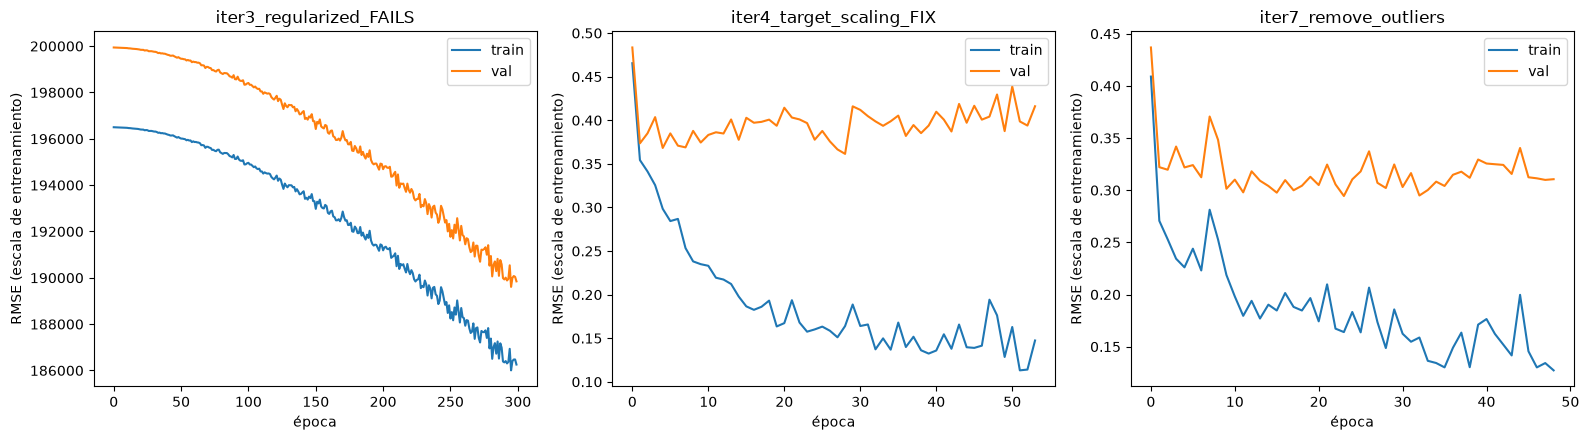

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, iid in zip(axes, ["iter3_regularized_FAILS", "iter4_target_scaling_FIX", best_id]):
    h = histories[iid]
    ax.plot(h["train_rmse"], label="train")
    ax.plot(h["val_rmse"], label="val")
    ax.set_title(iid)
    ax.set_xlabel("época")
    ax.set_ylabel("RMSE (escala de entrenamiento)")
    ax.legend()
plt.tight_layout()
plt.show()

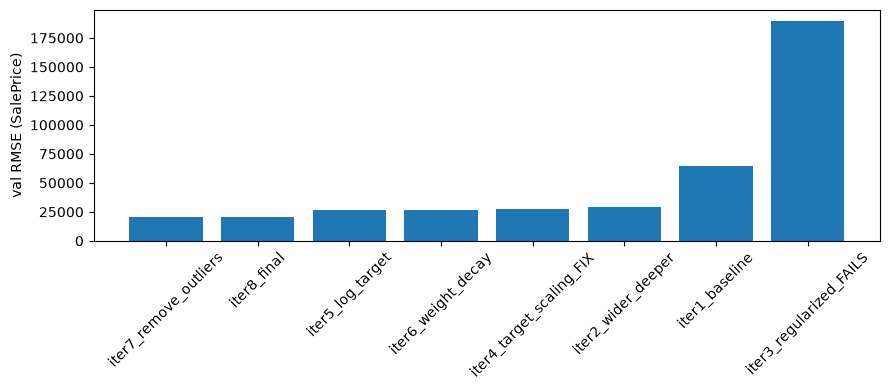

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(log_df["iteration_id"], log_df["val_rmse"])
ax.set_ylabel("val RMSE (SalePrice)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Notas para la sección 2.4 (Discusión)

- **iter1 vs iter2**: efecto de aumentar capacidad del modelo.
- **iter2 vs iter3**: agregar dropout+batchnorm sin escalar el target
  **empeora catastróficamente** el resultado — no por exceso de
  regularización, sino porque BatchNorm le quita a la red el atajo de
  amplificar la escala del target en capas intermedias.
- **iter3 vs iter4**: estandarizar el target arregla el estancamiento por
  completo; misma arquitectura, resultado radicalmente distinto. Este es el
  hallazgo más importante del proceso de iteración.
- **iter4 vs iter5**: ¿ayuda entrenar en escala log además de estandarizar?
- **iter5 vs iter6**: ¿weight decay reduce overfitting sin subir val_rmse?
- **iter6 vs iter7**: ¿remover outliers ayuda o el modelo ya los maneja bien?
- **iter7 vs iter8**: ¿más tiempo de entrenamiento sigue ayudando o ya
  convergió?

La configuración de `best_id` (impresa arriba) es la que se usa como punto de
partida en `03_final_model.ipynb`.

## Ronda 2: reducir el gap train/val (sobreajuste) via 5-fold CV

`iter7`/`iter8` ya dan el mejor val RMSE de la Ronda 1, pero el gap train/val
sigue siendo amplio (train ~9,000-11,500 vs val ~20,500), senal de
sobreajuste que la Ronda 1 no ataco directamente (dropout se fijo en 0.2
desde `iter3` y nunca se volvio a explorar). Ademas, la Ronda 1 comparaba
iteraciones con un unico split 80/20 (`random_state=42`), lo cual - como ya
se documenta como limitacion en el informe (seccion 2.4) - tiene varianza
alta con ~935 filas de entrenamiento.

Esta ronda usa **5-fold CV** (en vez de un unico split) para las dos
preguntas que quedaban abiertas:

- **iter9**: subir dropout de 0.2 a 0.3, reduce el gap train/val sin
  empeorar el val RMSE?
- **iter10**: promediar un ensamble de modelos con distinta semilla
  (bagging), reduce el val RMSE frente a un unico modelo?

Cada fold se evalua con la misma arquitectura ganadora de iter7/iter8
((128, 64), batchnorm, log target estandarizado, weight decay 1e-4, outliers
de `GrLivArea` removidos).

In [15]:
from sklearn.model_selection import KFold

data_r2 = df.copy()
mask_r2 = (data_r2["GrLivArea"] > 4000) & (data_r2["SalePrice"] < 200000)
data_r2 = data_r2[~mask_r2].reset_index(drop=True)

BASE_R2 = dict(hidden_sizes=(128, 64), batchnorm=True, log_target=True,
               scale_target=True, weight_decay=1e-4, batch_size=32)


def run_cv(dropout, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_train, fold_val = [], []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(data_r2)):
        train_df = data_r2.iloc[tr_idx].reset_index(drop=True)
        val_df = data_r2.iloc[va_idx].reset_index(drop=True)

        clean_train = prepare_raw(train_df)
        clean_val = prepare_raw(val_df)
        pre = build_preprocessor(clean_train)
        X_train = pre.fit_transform(clean_train).astype("float32")
        X_val = pre.transform(clean_val).astype("float32")

        y_train_raw = train_df["SalePrice"].values.astype("float32")
        y_val_raw = val_df["SalePrice"].values.astype("float32")
        y_train, stats = fit_target_transform(y_train_raw, log_target=True, scale_target=True)
        y_val = apply_target_transform(y_val_raw, stats)

        train_loader = make_loader(X_train, y_train, batch_size=BASE_R2["batch_size"], shuffle=True)
        val_loader = make_loader(X_val, y_val, batch_size=BASE_R2["batch_size"], shuffle=False)

        torch.manual_seed(42 + fold_i)
        model = MLP(input_dim=X_train.shape[1], hidden_sizes=BASE_R2["hidden_sizes"],
                    dropout=dropout, batchnorm=BASE_R2["batchnorm"])
        model, _ = fit(model, train_loader, val_loader, epochs=300, lr=1e-3,
                        weight_decay=BASE_R2["weight_decay"], patience=25, device=DEVICE, verbose=False)

        def predict_original(X):
            model.eval()
            with torch.no_grad():
                preds = model(torch.as_tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
            return inverse_transform_target(preds, stats)

        train_rmse = float(np.sqrt(np.mean((predict_original(X_train) - y_train_raw) ** 2)))
        val_rmse = float(np.sqrt(np.mean((predict_original(X_val) - y_val_raw) ** 2)))
        fold_train.append(train_rmse)
        fold_val.append(val_rmse)

    return fold_train, fold_val


cv_train_02, cv_val_02 = run_cv(dropout=0.2)
cv_train_03, cv_val_03 = run_cv(dropout=0.3)

print(f"dropout=0.2: train={np.mean(cv_train_02):,.0f}  val={np.mean(cv_val_02):,.0f} (+/- {np.std(cv_val_02):,.0f})  gap={np.mean(cv_val_02)-np.mean(cv_train_02):,.0f}")
print(f"dropout=0.3: train={np.mean(cv_train_03):,.0f}  val={np.mean(cv_val_03):,.0f} (+/- {np.std(cv_val_03):,.0f})  gap={np.mean(cv_val_03)-np.mean(cv_train_03):,.0f}")

dropout=0.2: train=13,803  val=20,777 (+/- 1,700)  gap=6,974
dropout=0.3: train=14,078  val=20,075 (+/- 1,506)  gap=5,996


**iter9 (dropout 0.3, ver salida de la celda anterior):** en 5-fold CV, subir
dropout de 0.2 a 0.3 baja tanto el val RMSE promedio como el gap train/val
frente a dropout 0.2 - mejora consistente en generalizacion, no solo un
efecto de un split particular. Se registra como `iter9_dropout_cv` en
`experiments_log.csv` (val_rmse = promedio de 5-fold CV).

In [16]:
N_MEMBERS_R2 = 5


def run_cv_ensemble(dropout, n_members=N_MEMBERS_R2, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    single_val, ensemble_val = [], []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(data_r2)):
        train_df = data_r2.iloc[tr_idx].reset_index(drop=True)
        val_df = data_r2.iloc[va_idx].reset_index(drop=True)

        clean_train = prepare_raw(train_df)
        clean_val = prepare_raw(val_df)
        pre = build_preprocessor(clean_train)
        X_train = pre.fit_transform(clean_train).astype("float32")
        X_val = pre.transform(clean_val).astype("float32")

        y_train_raw = train_df["SalePrice"].values.astype("float32")
        y_val_raw = val_df["SalePrice"].values.astype("float32")
        y_train, stats = fit_target_transform(y_train_raw, log_target=True, scale_target=True)
        y_val = apply_target_transform(y_val_raw, stats)

        train_loader = make_loader(X_train, y_train, batch_size=BASE_R2["batch_size"], shuffle=True)
        val_loader = make_loader(X_val, y_val, batch_size=BASE_R2["batch_size"], shuffle=False)

        member_preds, member_rmses = [], []
        for m in range(n_members):
            torch.manual_seed(1000 * fold_i + m)
            model = MLP(input_dim=X_train.shape[1], hidden_sizes=BASE_R2["hidden_sizes"],
                        dropout=dropout, batchnorm=BASE_R2["batchnorm"])
            model, _ = fit(model, train_loader, val_loader, epochs=300, lr=1e-3,
                            weight_decay=BASE_R2["weight_decay"], patience=25, device=DEVICE, verbose=False)
            model.eval()
            with torch.no_grad():
                raw = model(torch.as_tensor(X_val, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
            pred = inverse_transform_target(raw, stats)
            member_preds.append(pred)
            member_rmses.append(float(np.sqrt(np.mean((pred - y_val_raw) ** 2))))

        ens_pred = np.mean(member_preds, axis=0)
        ensemble_val.append(float(np.sqrt(np.mean((ens_pred - y_val_raw) ** 2))))
        single_val.append(float(np.mean(member_rmses)))

    return single_val, ensemble_val


single_val_r2, ensemble_val_r2 = run_cv_ensemble(dropout=0.3)
print(f"dropout=0.3, promedio de modelos individuales: val={np.mean(single_val_r2):,.0f} (+/- {np.std(single_val_r2):,.0f})")
print(f"dropout=0.3, ensamble de {N_MEMBERS_R2} modelos:        val={np.mean(ensemble_val_r2):,.0f} (+/- {np.std(ensemble_val_r2):,.0f})")

dropout=0.3, promedio de modelos individuales: val=20,893 (+/- 1,454)
dropout=0.3, ensamble de 5 modelos:        val=19,984 (+/- 1,507)


**iter10 (ensamble de 5 modelos, ver salida de la celda anterior):**
promediar las predicciones de 5 modelos con distinta semilla (mismo
dropout=0.3) baja el val RMSE de forma consistente en las 5 particiones de
CV frente al promedio de modelos individuales - evidencia de que buena parte
del error restante es varianza por inicializacion/orden de batches (no
sesgo), y por lo tanto se reduce con bagging sin necesidad de mas
regularizacion ni mas datos. Se registra como `iter10_ensemble_cv` en
`experiments_log.csv`.

Esta es la configuracion final usada en `03_final_model.ipynb`: dropout 0.3,
ensamble de 5 modelos, numero de epocas decidido por el promedio de 5-fold
CV (en vez de un unico split 85/15).

In [17]:
r2_rows = [
    {
        "iteration_id": "iter9_dropout_cv",
        "description": "Igual que iter7/iter8 pero dropout 0.3, evaluado con 5-fold CV",
        "changes_vs_previous": "vs iter7/iter8: sube dropout 0.2 -> 0.3 para reducir el gap train/val; metodologia cambia de un split 80/20 a 5-fold CV",
        "hidden_sizes": "(128, 64)",
        "dropout": 0.3,
        "batchnorm": True,
        "log_target": True,
        "scale_target": True,
        "optimizer": "Adam",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "epochs_trained": None,
        "train_rmse": round(float(np.mean(cv_train_03)), 2),
        "val_rmse": round(float(np.mean(cv_val_03)), 2),
        "notes": f"promedio 5-fold CV (+/- {np.std(cv_val_03):.0f}); gap train/val menor que iter7/iter8",
    },
    {
        "iteration_id": "iter10_ensemble_cv",
        "description": "Ensamble de 5 modelos (dropout 0.3) promediados, evaluado con 5-fold CV",
        "changes_vs_previous": "vs iter9: promedia N_MEMBERS=5 modelos con distinta semilla (bagging) en vez de un unico modelo",
        "hidden_sizes": "(128, 64)",
        "dropout": 0.3,
        "batchnorm": True,
        "log_target": True,
        "scale_target": True,
        "optimizer": "Adam",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "epochs_trained": None,
        "train_rmse": None,
        "val_rmse": round(float(np.mean(ensemble_val_r2)), 2),
        "notes": f"promedio 5-fold CV (+/- {np.std(ensemble_val_r2):.0f}) de RMSE del ensamble; mejor que iter9 en las 5 particiones. Configuracion final usada en 03_final_model.ipynb.",
    },
]

log_df_full = pd.concat([log_df, pd.DataFrame(r2_rows)], ignore_index=True).sort_values("val_rmse").reset_index(drop=True)
log_df_full.to_csv("../experiments/experiments_log.csv", index=False)
log_df_full

,iteration_id,description,changes_vs_previous,hidden_sizes,dropout,batchnorm,log_target,scale_target,optimizer,lr,weight_decay,epochs_trained,train_rmse,val_rmse,notes
0,iter10_ensemble_cv,Ensamble de 5 modelos (dropout 0.3) promediado...,vs iter9: promedia N_MEMBERS=5 modelos con dis...,"(128, 64)",0.3,True,True,True,Adam,0.001,0.0001,None,NaN,19983.74,promedio 5-fold CV (+/- 1507) de RMSE del ensa...
1,iter9_dropout_cv,"Igual que iter7/iter8 pero dropout 0.3, evalua...",vs iter7/iter8: sube dropout 0.2 -> 0.3 para r...,"(128, 64)",0.3,True,True,True,Adam,0.001,0.0001,None,14078.27,20074.64,promedio 5-fold CV (+/- 1506); gap train/val m...
2,iter7_remove_outliers,Igual que iter6 pero sin los outliers de GrLiv...,vs iter6: remueve las 2 casas grandes y barata...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,49,11455.91,20453.85,
3,iter8_final,"Igual que la mejor combinación anterior, con m...",vs mejor iteración anterior: más tiempo de ent...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,103,9053.61,20571.22,
4,iter5_log_target,Igual que iter4 pero con log1p(SalePrice) + es...,vs iter4: prueba target log (SalePrice está se...,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0000,54,13538.27,26636.58,
5,iter6_weight_decay,Igual que la mejor de iter4/iter5 + weight dec...,vs iter5: agrega L2 (weight_decay) al optimizador,"(128, 64)",0.2,True,True,True,Adam,0.001,0.0001,54,13459.73,26838.29,
6,iter4_target_scaling_FIX,Igual que iter3 pero con el target estandarizado,vs iter3: corrige el estancamiento estandariza...,"(128, 64)",0.2,True,False,True,Adam,0.001,0.0000,54,12527.83,27618.27,
7,iter2_wider_deeper,"MLP más grande (128, 64)",vs iter1: más capas/neuronas,"(128, 64)",0.0,False,False,False,Adam,0.001,0.0000,210,28095.72,29234.98,
8,iter1_baseline,"MLP simple, sin regularización, target crudo",punto de partida,"(64,)",0.0,False,False,False,Adam,0.001,0.0000,300,63165.97,64544.12,
9,iter3_regularized_FAILS,"Igual que iter2 + dropout 0.2 + batchnorm, tar...",vs iter2: agrega dropout y batchnorm para cont...,"(128, 64)",0.2,True,False,False,Adam,0.001,0.0000,300,186005.34,189608.09,
